# Double pendulum

https://en.wikipedia.org/wiki/Double_pendulum#

## Imports

In [2]:
import numpy as np
import sympy as smp
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import PillowWriter

Define all appropriate symbols using sympy.

In [3]:
t, g = smp.symbols('t, g')
m1, m2 = smp.symbols('m1, m2')
L1, L2 = smp.symbols('L1, L2')

Angles $\theta_1$ and $\theta_2$ are functions of time (which we will eventually solve for). We need to define!

In [4]:
the1, the2 = smp.symbols(r'\theta_1, \theta_2', cls=smp.Function)

Explicitly writing them as function of $t$; time:

In [5]:
the1 = the1(t)
the2 = the2(t)

In [6]:
the1

\theta_1(t)

Define derivatives and second derivatives

In [7]:
the1_d = smp.diff(the1, t)
the2_d = smp.diff(the2, t)
the1_dd = smp.diff(the1_d, t)
the2_dd = smp.diff(the2_d, t)

Define $x_1, y_1, x_2, y_2$ written in parameters above

In [8]:
x1 = L1*smp.sin(the1)
y1 = -L1*smp.cos(the1)
x2 = L1*smp.sin(the1) + L2*smp.sin(the2)
y2 = -L1*smp.cos(the1) + L2*smp.cos(the2)

In [9]:
x1

L1*sin(\theta_1(t))

In [10]:
x2

L1*sin(\theta_1(t)) + L2*sin(\theta_2(t))

Then use these to define kinetic and potential energy for each mass. Hence, obtain Lagrangian

In [11]:
# Kinetic
T1 = 1/2 * m1 * (smp.diff(x1, t)**2 + smp.diff(y1, t)**2)
T2 = 1/2 * m2 * (smp.diff(x2, t)**2 + smp.diff(y2, t)**2)
T = T1 + T2

# Potential
V1 = m1*g*y1
V2 = m2*g*y2
V = V1 + V2

# Lagrangian
L = T - V

In [12]:
L

L1*g*m1*cos(\theta_1(t)) - g*m2*(-L1*cos(\theta_1(t)) + L2*cos(\theta_2(t))) + 0.5*m1*(L1**2*sin(\theta_1(t))**2*Derivative(\theta_1(t), t)**2 + L1**2*cos(\theta_1(t))**2*Derivative(\theta_1(t), t)**2) + 0.5*m2*((L1*sin(\theta_1(t))*Derivative(\theta_1(t), t) - L2*sin(\theta_2(t))*Derivative(\theta_2(t), t))**2 + (L1*cos(\theta_1(t))*Derivative(\theta_1(t), t) + L2*cos(\theta_2(t))*Derivative(\theta_2(t), t))**2)

Get Lagrange equations of motion (e. o. m.)
$$
    \begin{align}
        \frac{\partial L}{\partial \theta_1} - \frac{d}{dt} \frac{\partial L}{\partial \dot{\theta}_1} &= 0 \\
        \frac{\partial L}{\partial \theta_2} - \frac{d}{dt} \frac{\partial L}{\partial \dot{\theta}_2} &= 0
    \end{align}
$$

In [13]:
LEM1 = smp.diff(L, the1) - smp.diff(smp.diff(L, the1_d), t).simplify()
LEM2 = smp.diff(L, the2) - smp.diff(smp.diff(L, the2_d), t).simplify()

In [14]:
LEM1

-L1*g*m1*sin(\theta_1(t)) - L1*g*m2*sin(\theta_1(t)) - 1.0*L1*(L1*m1*Derivative(\theta_1(t), (t, 2)) + L1*m2*Derivative(\theta_1(t), (t, 2)) - L2*m2*sin(\theta_1(t) + \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t) - L2*m2*sin(\theta_1(t) + \theta_2(t))*Derivative(\theta_2(t), t)**2 + L2*m2*cos(\theta_1(t) + \theta_2(t))*Derivative(\theta_2(t), (t, 2))) + 0.5*m2*(2*L1*(L1*sin(\theta_1(t))*Derivative(\theta_1(t), t) - L2*sin(\theta_2(t))*Derivative(\theta_2(t), t))*cos(\theta_1(t))*Derivative(\theta_1(t), t) - 2*L1*(L1*cos(\theta_1(t))*Derivative(\theta_1(t), t) + L2*cos(\theta_2(t))*Derivative(\theta_2(t), t))*sin(\theta_1(t))*Derivative(\theta_1(t), t))

Solve Lagrange e. o. m. (assuming both are equal to zero)

In [15]:
sols = smp.solve([LEM1,LEM2], (the1_dd, the2_dd),
                 simplify=False, rational=False)

In [16]:
sols

{Derivative(\theta_1(t), (t, 2)): -1.0*L1*m2*sin(\theta_1(t) + \theta_2(t))*cos(\theta_1(t) + \theta_2(t))*Derivative(\theta_1(t), t)**2/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) + \theta_2(t))**2 + 1.0*L1*m2) - 1.0*L1*m2*sin(\theta_1(t) + \theta_2(t))*cos(\theta_1(t) + \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) + \theta_2(t))**2 + 1.0*L1*m2) + 1.0*L1*m2*sin(\theta_1(t))*cos(\theta_1(t) + \theta_2(t))*cos(\theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) + \theta_2(t))**2 + 1.0*L1*m2) + 1.0*L1*m2*sin(\theta_2(t))*cos(\theta_1(t) + \theta_2(t))*cos(\theta_1(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) + \theta_2(t))**2 + 1.0*L1*m2) + 1.0*L2*m2*sin(\theta_1(t) + \theta_2(t))*Derivative(\theta_1(t), t)*Derivative(\theta_2(t), t)/(1.0*L1*m1 - 1.0*L1*m2*cos(\theta_1(t) + \theta_2(t))**2 + 1.0*L1*m2) + 1.0*L2*m2*sin(\theta_1(t

Now we have
* $\frac{d^2 \theta_1}{dt^2} = \dots$
* $\frac{d^2 \theta_2}{dt^2} = \dots$

These are two second order ODEs, they have to be transformed into first order ODEs, four in total:
1. Define $z_1 = \frac{d\theta_1}{dt}$ and $z_2 = \frac{d\theta_2}{dt}$
2. Then $\frac{dz_1}{dt} = \frac{d^2\theta_1}{dt^2}$ and $\frac{dz_2}{dt} = \frac{d^2\theta_2}{dt^2}$

Accordingly, we get $4$ first order ODEs (as opposed to 2 second order ones)
* $\frac{dz_1}{dt} = \dots$
* $\frac{d\theta_1}{dt} = z_1$
* $\frac{dz_2}{dt} = \dots$
* $\frac{d\theta_2}{dt} = z_2$

We need to convert the _symbolic_ expressions above to numerical functions so we can use them in a numerical python solver. For this we use `smp.lambdify`

In [17]:
dz1dt_f = smp.lambdify((t,g,m1,m2,L1,L2,the1,the2,the1_d,the2_d), sols[the1_dd])
dz2dt_f = smp.lambdify((t,g,m1,m2,L1,L2,the1,the2,the1_d,the2_d), sols[the2_dd])
dthe1dt_f = smp.lambdify(the1_d, the1_d)
dthe2dt_f = smp.lambdify(the2_d, the2_d)

In [18]:
dz1dt_f

<function _lambdifygenerated(t, g, m1, m2, L1, L2, _Dummy_45, _Dummy_44, _Dummy_43, _Dummy_42)>

Now define $\vec{S} = (\theta_1, z_1, \theta_2, z_2$. We need to write a function that takes $\vec{S}$ and $t$ and returns $d\vec{S}(t)/dt$

In [19]:
# Take function S
# Return dSdt
def dSdt(S, t, g, m1, m2, L1, L2):
    the1, z1, the2, z2 = S
    return [
        dthe1dt_f(z1),
        dz1dt_f(t, g, m1, m2, L1, L2, the1, the2, z1, z2),
        dthe2dt_f(z2),
        dz2dt_f(t, g, m1, m2, L1, L2, the1, the2, z1, z2),
    ]

Solve the system of ODEs using scipys `odeint` method

In [20]:
t = np.linspace(0, 40, 1001)
g = 9.81
m1=2
m2=1
L1 = 2
L2 = 1
ans = odeint(dSdt, y0=[1, -3, -1, 5], t=t, args=(g,m1,m2,L1,L2))

25 times per second (number of data points). This will be important for animating later on.

In [21]:
t[t<1]

array([0.  , 0.04, 0.08, 0.12, 0.16, 0.2 , 0.24, 0.28, 0.32, 0.36, 0.4 ,
       0.44, 0.48, 0.52, 0.56, 0.6 , 0.64, 0.68, 0.72, 0.76, 0.8 , 0.84,
       0.88, 0.92, 0.96])

In [22]:
ans.T

array([[ 1.        ,  0.87678998,  0.74752883, ...,  1.26775635,
         1.21449049,  1.14279095],
       [-3.        , -3.15822579, -3.30232419, ..., -1.08853907,
        -1.56902867, -2.00779071],
       [-1.        , -0.79948539, -0.59562795, ..., 84.63374614,
        84.8961453 , 85.13929691],
       [ 5.        ,  5.03943923,  5.16997168, ...,  6.79634692,
         6.3241224 ,  5.82364115]], shape=(4, 1001))

Obtain $\theta_1(t)$ and $\theta_2(t)$ from the answer

In [23]:
the1 = ans.T[0]
the2 = ans.T[1]

In [24]:
the1

array([1.        , 0.87678998, 0.74752883, ..., 1.26775635, 1.21449049,
       1.14279095], shape=(1001,))

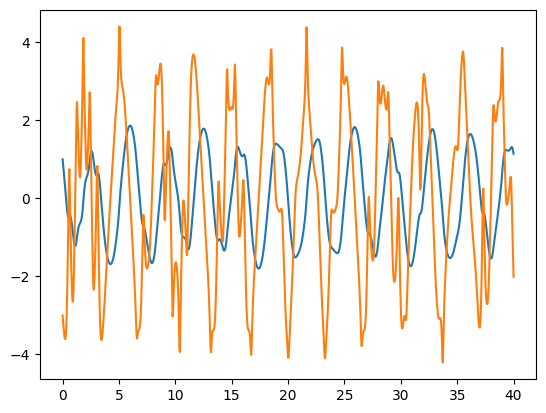

In [25]:
plt.plot(t, the1)
plt.plot(t, the2)

Funtion that takes $\theta_1$ and $\theta_2$, and returns the location $(x,y)$ of the two masses.

In [26]:
def get_x1y1x2y2(t, the1, the2, L1, L2):
    return (L1*np.sin(the1),
            -L1*np.cos(the1),
            L1*np.sin(the1) + L2*np.sin(the2),
            -L1*np.cos(the1) - L2*np.cos(the2))

x1, y1, x2, y2 = get_x1y1x2y2(t, ans.T[0], ans.T[2], L1, L2)

In [27]:
x1

array([1.68294197, 1.53737929, 1.35965711, ..., 1.90886741, 1.87438358,
       1.81959088], shape=(1001,))

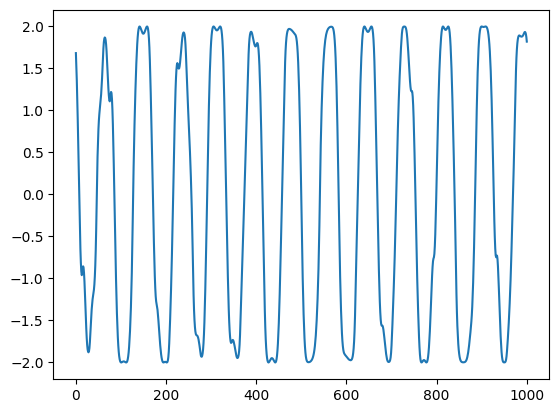

In [28]:
plt.plot(x1)

### Animation

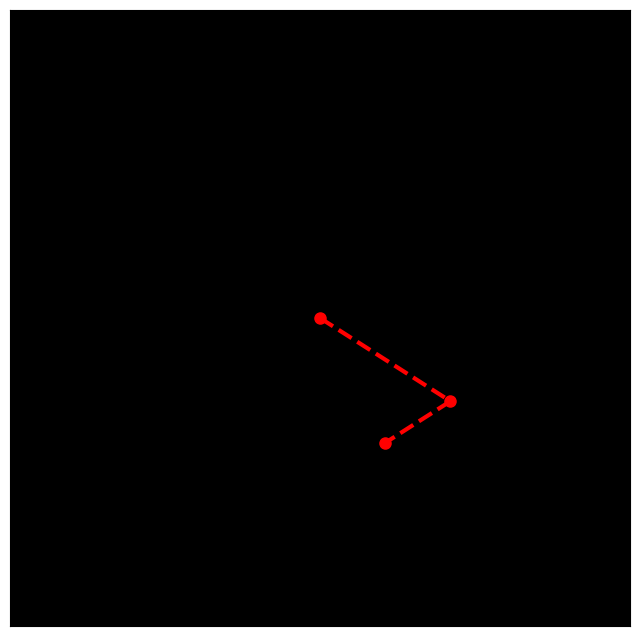

In [31]:
def animate(i):
    ln1.set_data([0, x1[i], x2[i]], [0, y1[i], y2[i]])
    
fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.set_facecolor('k')
ax.get_xaxis().set_ticks([])    # enable this to hide x axis ticks
ax.get_yaxis().set_ticks([])    # enable this to hide y axis ticks
ln1, = plt.plot([], [], 'ro--', lw=3, markersize=8)
ax.set_ylim(-4,4)
ax.set_xlim(-4,4)
ani = animation.FuncAnimation(fig, animate, frames=1000, interval=50)
ani.save('pen.gif',writer='pillow',fps=25)